## CNN NAS

In [25]:
import reward_functions
# Some magic so that the notebook will reload the external python script file any time you edit and save the .py file;
%load_ext autoreload
%autoreload 2

([('16', '3', '1'), ('64', '3', '0'), ('16', '3', '2'), ('32', '3', '0'), ('32', '1', '2')], tensor([[-3.6213],
        [-3.3981],
        [-3.4522],
        [-3.8858],
        [-3.6482]], grad_fn=<StackBackward0>))
CNNController(
  (embedding): Embedding(45, 8)
  (rnn): LSTM(8, 32, batch_first=True)
  (fc_filter): Linear(in_features=32, out_features=5, bias=True)
  (fc_kernel): Linear(in_features=32, out_features=3, bias=True)
  (fc_padding): Linear(in_features=32, out_features=3, bias=True)
  (meta_layer): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=False)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=False)
  )
)
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import torch
import torch.nn as nn
import time
from torch.utils.data import DataLoader
import os

import utils

import logging
logging.basicConfig(level=logging.INFO, filename=os.path.join(os.getcwd(), 'log.log'), filemode='w')

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)




device = utils.get_device_available()
print(torch.__version__)
print(device)

2.4.1
cuda


In [27]:
def is_valid_encoding(encoding):
    if len(encoding) < 3 or encoding[0] != "START" or encoding[-1] != "END":
        return False

    for i in range(1, len(encoding) - 1):
        if not encoding[i].isnumeric():
            return False

    return True


def split_dataset(data, labels, split_ratio=0.8):
    dataset = torch.utils.data.TensorDataset(data, labels)
    train_size = int(split_ratio * len(dataset))
    test_size = len(dataset) - train_size

    train_set, test_set = torch.utils.data.random_split(dataset, [train_size, test_size])

    train_data, train_labels = zip(*train_set)
    train_data = torch.stack(train_data)
    train_labels = torch.stack(train_labels)

    test_data, test_labels = zip(*test_set)
    test_data = torch.stack(test_data)
    test_labels = torch.stack(test_labels)

    return (train_data, train_labels), (test_data, test_labels)

### RL Loop

In [28]:
from CNN_NAS.ChildCNNModel import ChildCNNModel


def train_controller(
        controller,
        train,
        test=None,
        model_iters=5,
        train_epochs=10,
        negative_reward=-1,
        max_child_layers=5,
        positions=None,
        optimizer=None,
        baseline=0,
        reward_function=None,
        dataset_name=None
):
    
    if positions is None:
        positions=[1]
        max_child_layers=1
    if not test:
        train, test = split_dataset(*train)

    if reward_function is None:
        reward_function = reward_functions.test_accuracy_reward


    max_accuracy = 0

    train_x, train_y = train

    test_x, test_y = test
    
    if len(train_x.size())==3:
        train_x = train_x.unsqueeze(1)
        
    if len(test_x.size())==3:
        test_x = test_x.unsqueeze(1)
        
    logger.info(f"Training set shape: {train_x.size()}")

    num_channels = train_x.size(1)
    height = train_x.size(2)
    width = train_x.size(3)
    output_dim = torch.max(train_y).item() + 1

    if not optimizer:
        optimizer = torch.optim.Adam(controller.parameters(), lr=0.001)

    gamma = 0.9

    # baseline = 0

    print("Controller will be saved to: ", os.path.join("Models", "Controller", controller.type, f"{controller.name}.pt"))
    print("Best child model will be saved to: ", os.path.join("Models", "Child", controller.type, f"{controller.name}.pt"))
    print("Training results will be saved to: ", os.path.join("Results", "Controller", controller.type, f"{controller.name}.csv"))
    print()

    for iter in range(model_iters):
        logger.info(f"------ ITERATION {iter} ------")

        layer_encoding, log_probs = controller.generate_sequence(max_layers=max_child_layers)
        # print("Model encoding:", layer_encoding)
        logger.info(f"Layers generated: {str(layer_encoding)}")
        model_encoding  = utils.replace_multiple_conv_layers(base_model=base_model, generated_layers=layer_encoding, positions=positions, input_channels=num_channels)

        print(f"[ITER {iter}] Model encoding = {model_encoding}")
        
        child_model = ChildCNNModel(model_encoding, num_channels,height,width, output_dim).to(device)

        # print(child_model)
        logger.info(str(child_model))

        # Train child model
        child_model_loss, train_time = child_model.train_model(
            train_x,
            train_y,
            device,
            epochs=train_epochs
        )
        # print("CHILD MODEL LOSS:", child_model_loss, "with train time:", train_time)
        logger.info(f"CHILD MODEL LOSS: {child_model_loss} with train time {train_time}")

        # accuracy = child_model.evaluate_model(test_x, test_y, device)
        accuracy, val_loss, reward = reward_function(child_model, test, device=device,dataset_name=)

        # print("CHILD MODEL ACCURACY:", accuracy)
        logger.info(f"CHILD MODEL ACCURACY: {accuracy}")

        if accuracy > max_accuracy:
            max_accuracy = accuracy
            utils.save_child_model(child_model, accuracy, controller.name)

        # reward = accuracy

        print(f"train_loss: {child_model_loss}\tvalidation_loss: {val_loss}\ttest_acc: {accuracy}\ttrain_time: {train_time}\tpolicy_gradient: {reward}")

        advantage = torch.tensor([reward - baseline], dtype=torch.float32, device=log_probs[0].device)
        policy_gradient = -torch.sum(log_probs) * advantage.detach()

        baseline = (1 - gamma) * reward + gamma * baseline

        optimizer.zero_grad()
        policy_gradient.backward()
        optimizer.step()

        utils.save_progress(
            controller,
            optimizer,
            baseline,
            row_data=map(str,[child_model_loss, val_loss, accuracy, train_time, policy_gradient.item(), max_accuracy, baseline]),
            controller_type="CNN",
            headers=("train_loss", "val_loss", "test_acc", "train_time", "policy_gradient", "max_accuracy", "baseline")
        )


        # print("Policy gradient:", policy_gradient.item())
        logger.info(f"Policy gradient: {policy_gradient.item()}")
        
        utils.cleanup_child_model(child_model)
        logger.info("")

        print()
        
    return controller,optimizer

# Is It Okay If Higher Accuracy → Higher Loss (policy gradient)?
#
# Yes, because you're minimizing negative reward-weighted log-probabilities:
#
# Higher reward = higher positive loss value = stronger update in backward()
# Lower reward = smaller or even negative advantage = smaller gradient or a push in the opposite direction
# Loss value increasing is not a problem — because you’re not minimizing “loss” in the usual supervised learning sense — you're maximizing expected reward through gradient ascent via REINFORCE.


### CIFAR Dataset

In [29]:
# train_data = (torch.load(data_path + 'cifar/train_data.pt'), torch.load(data_path + 'cifar/train_label.pt'))
# test_data = (torch.load(data_path + 'cifar/test_data.pt'), torch.load(data_path + 'cifar/test_label.pt'))

# model_iters=1
# train_epochs=1
# trained_controller,optimizer = train_controller(CNNController(name="EXP_1_CIFAR", meta=[32, 10]), train_data, test_data, model_iters=model_iters, train_epochs=train_epochs, negative_reward=-1,
#                  max_child_layers=1)

# # save_controller(trained_controller,optimizer, f"CIFAR-10_MI{model_iters}_TE{train_epochs}_controller")

### Experiment 4 - Can an RNN controller trained on one dataset help converge faster on a similar dataset when fine-tuned?

In [30]:
experiment_name = "EXP_4"
fresh_controller= "CIFAR_100_Trained_model_"+experiment_name

In [31]:
utils.reset_experiment(fresh_controller)

## First Dataset - CIFAR100

In [32]:
dataset="cifar100"

data_path = utils.check_cifar100_dataset_exists()

dataset_train_data = (torch.load(data_path + f'{dataset}/train_data.pt', weights_only=True), torch.load(data_path + f'{dataset}/train_label.pt', weights_only=True))

dataset_test_data = (torch.load(data_path + f'{dataset}/test_data.pt', weights_only=True), torch.load(data_path + f'{dataset}/test_label.pt', weights_only=True))

train_data = torch.load(data_path + f'{dataset}/train_data.pt',weights_only=True)
num_channels = 1

if len(train_data.size())==4:
    num_channels=train_data.size(1)

img_size = train_data.size(-1)

train_label = torch.load(data_path + f'{dataset}/train_label.pt',weights_only=True)

num_classes = train_label.unique().size(0)

print(f"Image size: {img_size}")
print(f"Number of channels: {num_channels}")
print(f"Number of classes:  {num_classes}")



CIFAR-100 dataset missing - downloading...


  4%|▍         | 6750208/169001437 [02:53<1:09:37, 38842.63it/s]


Failed download. Trying https -> http instead. Downloading http://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz to ../../data/cifar100/temp\cifar-100-python.tar.gz


100%|██████████| 169001437/169001437 [00:14<00:00, 11636662.01it/s]


Extracting ../../data/cifar100/temp\cifar-100-python.tar.gz to ../../data/cifar100/temp
Files already downloaded and verified
Image size: 32
Number of channels: 3
Number of classes:  100


## Load  predefined model encoding

In [20]:
import predefined_models
# Defined by data


base_model = predefined_models.get_benchmarkModel(input_channels=num_channels, output_dim=num_classes)

In [24]:
from CNN_NAS.CNNController import CNNController

#Load and run
logger.info("###############################################")
logger.info("STARTING TRAINING")
logger.info("###############################################")

try:
    meta_controller, optimizer, baseline = utils.load_controller(fresh_controller)
except FileNotFoundError:
    meta_controller = CNNController(name=fresh_controller, meta=torch.tensor([[img_size, num_classes]], dtype=torch.float))
    baseline = 0
    optimizer = None



model_iters=300
train_epochs=10
trained_controller, optimizer = train_controller(
    meta_controller,
    dataset_train_data,
    dataset_test_data,
    model_iters=model_iters,
    train_epochs=train_epochs,
    negative_reward=-1,
    max_child_layers=2,
    positions=[1,2],
    baseline=baseline,
    optimizer=optimizer,
    dataset_name=dataset
)

C:\Users\vaibh\IdeaProjects\Python\neural-arch-search-cs5242\utils.py:382: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  optimizer = torch.optim.Adam(controller.parameters()

Controller and optimizer loaded from: Models\Controller\CNN\CIFAR_Trained_model_EXP_4.pt
Controller will be saved to:  Models\Controller\CNN\CIFAR_Trained_model_EXP_4.pt
Best child model will be saved to:  Models\Child\CNN\CIFAR_Trained_model_EXP_4.pt
Training results will be saved to:  Results\Controller\CNN\CIFAR_Trained_model_EXP_4.csv

Number of layers generated 2
prev out_channels 256
prev out_channels 32
[ITER 0] Model encoding = [[[3, 256, 3, 1], [2, 2], [256, 32, 5, 2], [2, 2], [32, 256, 5, 0], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 2.302382343292236	validation_loss: 2.301228628158569	test_acc: 0.1	train_time: 6.792161703109741	policy_gradient: 0.1

Number of layers generated 2
prev out_channels 256
prev out_channels 128
[ITER 1] Model encoding = [[[3, 256, 3, 1], [2, 2], [256, 128, 3, 0], [2, 2], [128, 64, 3, 1], [2, 2]], [[1024, 512], [512, 256], [256, 10]]]
train_loss: 2.302631938934326	validation_loss: 2.302029223442078	test_acc: 0.0996	train_time: 6.254

KeyboardInterrupt: 

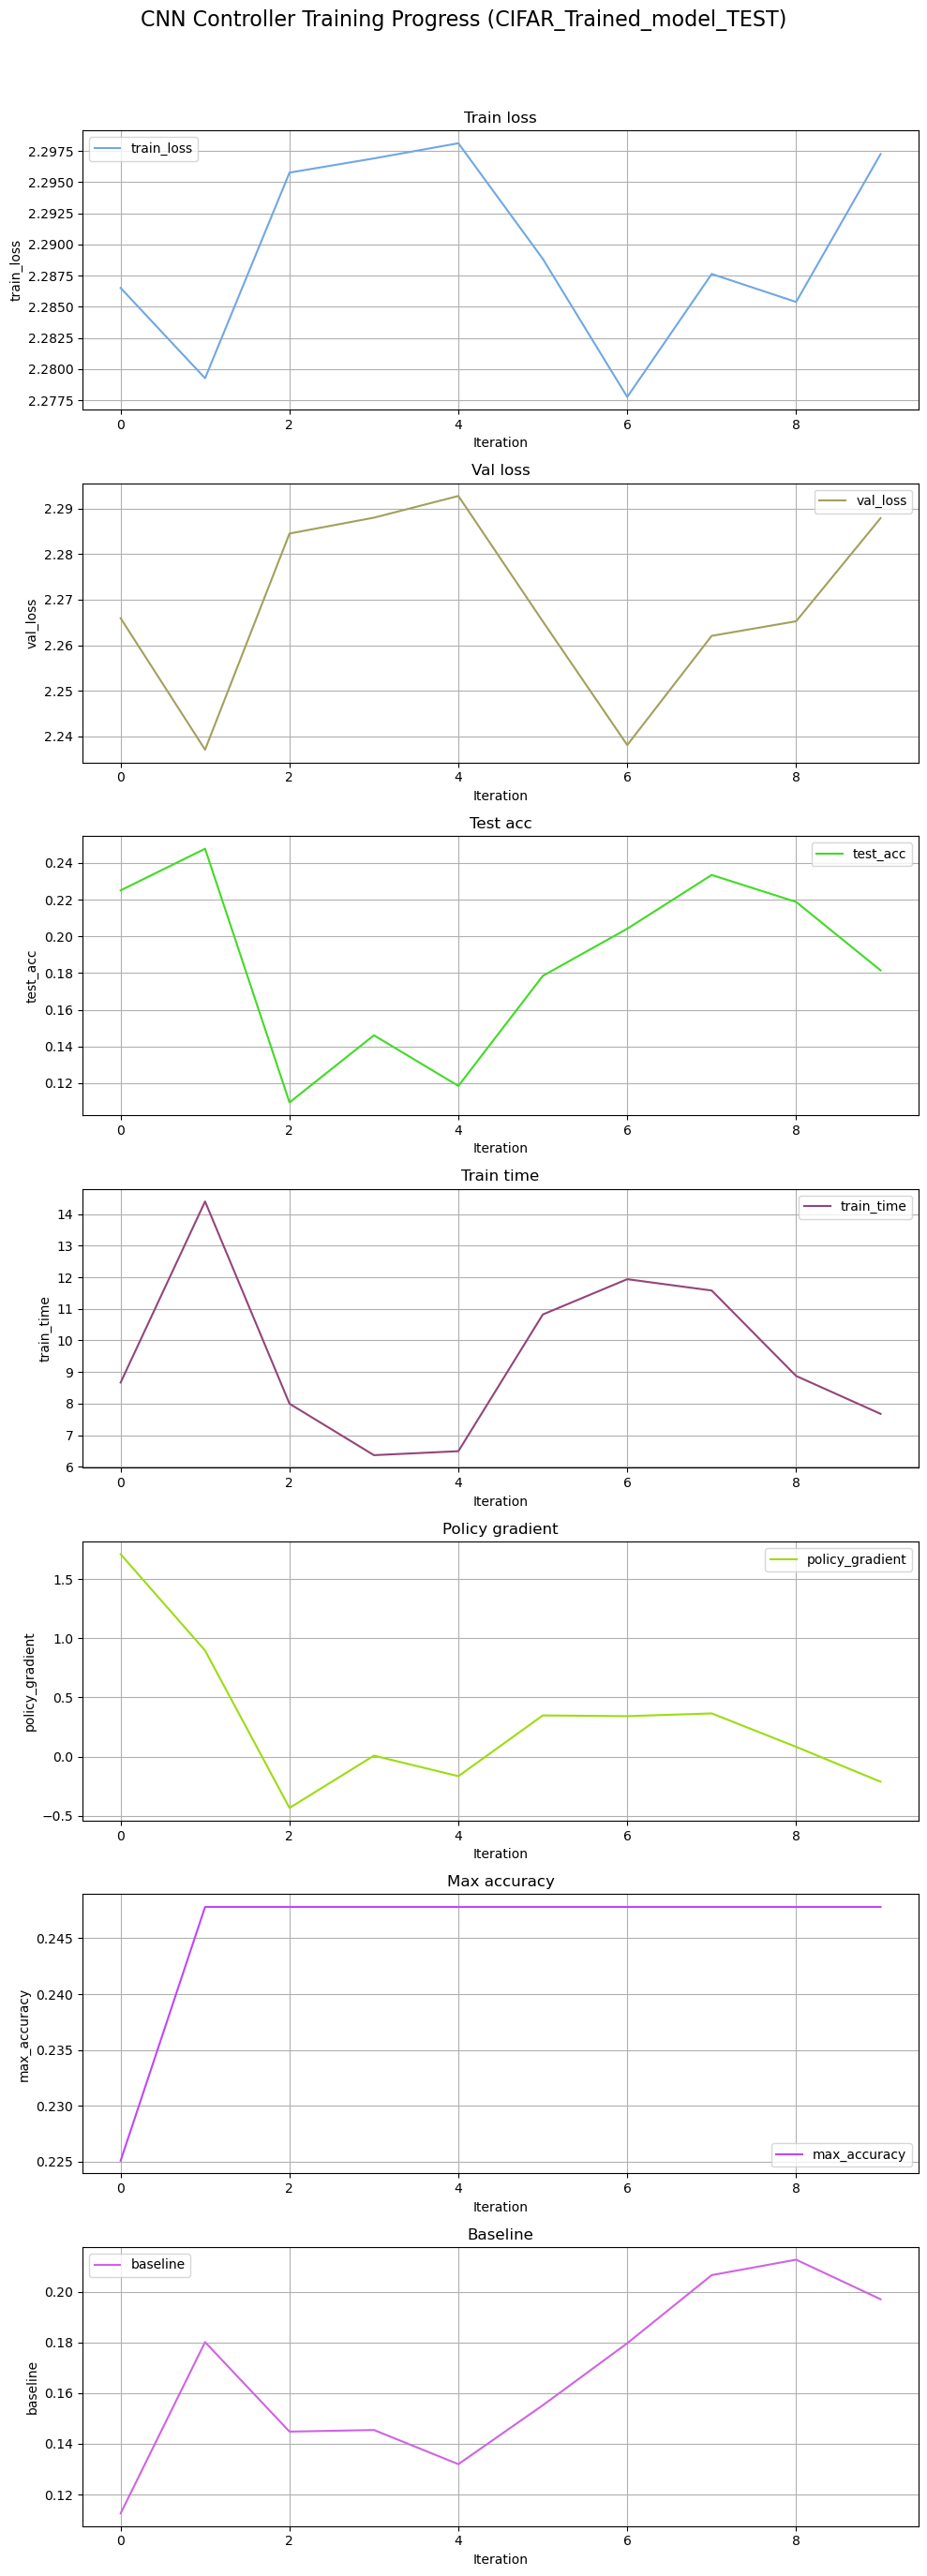

In [82]:
utils.plot_metrics(fresh_controller)

### MNIST Dataset

In [69]:
# train_data = (torch.load(data_path + 'mnist/train_data.pt',weights_only=True), torch.load(data_path + 'mnist/train_label.pt',weights_only=True))
# test_data = (torch.load(data_path + 'mnist/train_data.pt',weights_only=True), torch.load(data_path + 'mnist/train_label.pt',weights_only=True))
# 
# train_controller(CNNController(), train_data, test_data, model_iters=20, train_epochs=10, negative_reward=-1,
#                  max_child_layers=1)